# Baseline colorization model with autoencoder-like architecture

## Imports

In [26]:
#Algebra
import numpy as np

#Graphics
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

#Deep learning
import tensorflow as tf
import tensorflow_io as tfio

from keras.models import Model
from keras import optimizers, callbacks
from keras.layers import  Input, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten, Dense, Reshape
from keras.utils import image_dataset_from_directory

#Pretrained model for transfer learning


#Saving models
import joblib

## Training dataset

In [27]:
train_data_dir = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color'

## Parameters

In [28]:
BATCH_SIZE = 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
NUM_CHANNELS = 3

SEED = 42

LEARNING_RATE = 0.01
PATIENCE = 5
EPOCHS = 40

In [29]:
train_ds, val_ds = image_dataset_from_directory(
    train_data_dir,
    labels=None,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 5000 files.
Using 4000 files for training.
Using 1000 files for validation.


## Converting RGB to Lab

In [30]:
def rgb_to_lab(image):
    images = tf.cast(image, tf.float32) / 255.0
    lab = tfio.experimental.color.rgb_to_lab(image)
    L = lab[:, :, :, :1] / 100.
    ab = lab[:, :, :, 1:] / 128.
    return (L, ab)

In [31]:
train_ds_lab = train_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_lab = train_ds_lab.prefetch(tf.data.AUTOTUNE)
val_ds_lab = val_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_lab = val_ds_lab.prefetch(tf.data.AUTOTUNE)

## Defining the model

In [32]:
def initialize_model():

    ######################
    ###  Architecture  ###
    ######################

    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))  #B&W images (L channel)

    #Encoder part
    x = Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    #Decoder part
    x = Conv2DTranspose(64, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)

    x = Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)

    outputs = Conv2DTranspose(2, kernel_size=(3, 3), strides=(2, 2), activation='tanh', padding='same')(x)  #ab channels

    
    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='mse',
              optimizer=adam,
              metrics=['mse'])

    return model

In [33]:
baseline = initialize_model()
baseline.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 256, 256, 2)    │           578 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,506 (724.63 KB)

 Trainable params: 185,506 (724.63 KB)

 Non-trainable params: 0 (0.00 B)

### Callbacks

In [34]:
LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

### Training

In [35]:
%%time
history = baseline.fit(train_ds_lab,
                    epochs=EPOCHS,
                    validation_data=val_ds_lab,
                    callbacks=[LRreducer, EarlyStopper],
                    verbose=1)

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 286ms/step - loss: 102.4919 - mse: 102.4919 - val_loss: 99.8928 - val_mse: 99.8928 - learning_rate: 0.0100
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 285ms/step - loss: 102.7416 - mse: 102.7416 - val_loss: 99.8928 - val_mse: 99.8928 - learning_rate: 0.0100
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - loss: 103.0373 - mse: 103.0373 - val_loss: 99.8928 - val_mse: 99.8928 - learning_rate: 0.0100
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 102.4718 - mse: 102.4718
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - loss: 102.4618 - mse: 102.4618 - val_loss: 99.8928 - val_mse: 99.8928 - learning_rate: 0.0100
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 286ms/step - loss: 102.6526 - mse: 102.6526 - val_loss: 99.8928 - val_mse: 99.8928 - learning_rate: 1.0000e-03
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 281ms/step - loss: 103.4732 - mse: 103.4732 -

In [36]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["mse"], label="Train MSE")
    ax[1].plot(history.epoch, history.history["val_mse"], label="Validation MSE")
    ax[0].legend()
    ax[1].legend()

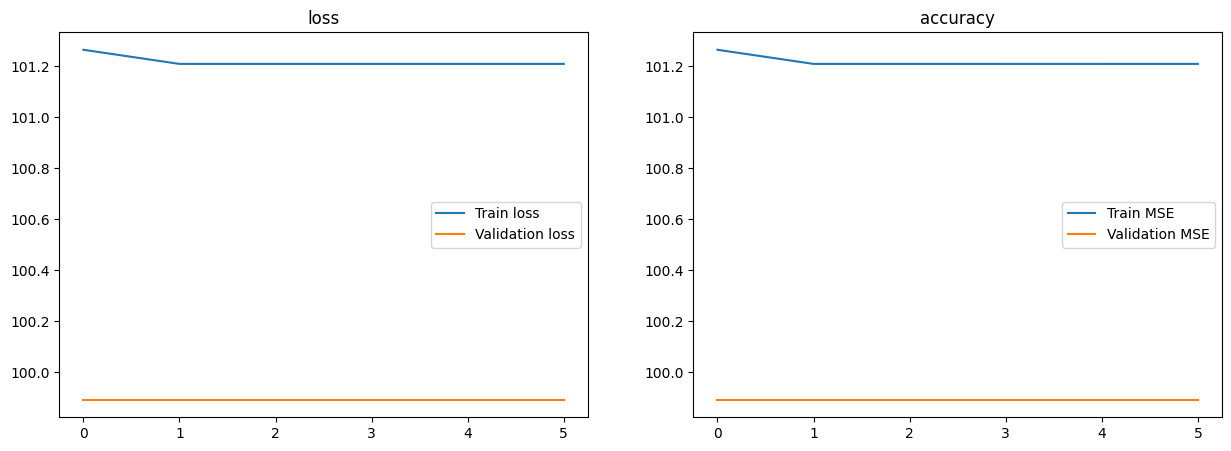

In [37]:
plot_history(history)